# F1 Data

Fun with F1 data!

October 2025

Using data from Traciing Insights website:

https://tracinginsights.com/data/

Which has historical racing trajectory data on github:

https://github.com/TracingInsights-Archive

## Data available 

In folders, organized by race. Also some

In [2]:
import os

directory_path = "./f1/2025"  # Current directory, change as needed

for item in os.listdir(directory_path):
    full_path = os.path.join(directory_path, item)
    if os.path.isdir(full_path):
        print(f"📁 {item} (Directory)")
    else:
        print(f"📄 {item} (File)")


📁 Emilia Romagna Grand Prix (Directory)
📁 Miami Grand Prix (Directory)
📄 telFP3.py (File)
📁 Azerbaijan Grand Prix (Directory)
📁 Italian Grand Prix (Directory)
📁 Pre-Season Testing (Directory)
📁 Singapore Grand Prix (Directory)
📁 cache (Directory)
📄 LICENSE (File)
📄 requirements.txt (File)
📄 Banner.png (File)
📄 telFP2.py (File)
📄 CITATION.cff (File)
📁 Austrian Grand Prix (Directory)
📁 Dutch Grand Prix (Directory)
📁 British Grand Prix (Directory)
📁 Saudi Arabian Grand Prix (Directory)
📄 telSQ.py (File)
📁 Belgian Grand Prix (Directory)
📁 Australian Grand Prix (Directory)
📄 telR.py (File)
📁 Spanish Grand Prix (Directory)
📄 telSR.py (File)
📄 README.md (File)
📁 fastf1_cache (Directory)
📁 Bahrain Grand Prix (Directory)
📁 Hungarian Grand Prix (Directory)
📄 telQ.py (File)
📄 .gitignore (File)
📄 utils.py (File)
📁 .github (Directory)
📄 standings.json (File)
📄 tel.py (File)
📁 Monaco Grand Prix (Directory)
📁 Japanese Grand Prix (Directory)
📁 Canadian Grand Prix (Directory)
📁 Chinese Grand Prix (Dire

req         WARNING 	DEFAULT CACHE ENABLED! (59.08 MB) /Users/nathanverrill/Library/Caches/fastf1
logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
req            INFO 	Data has been written to cache!
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached dat

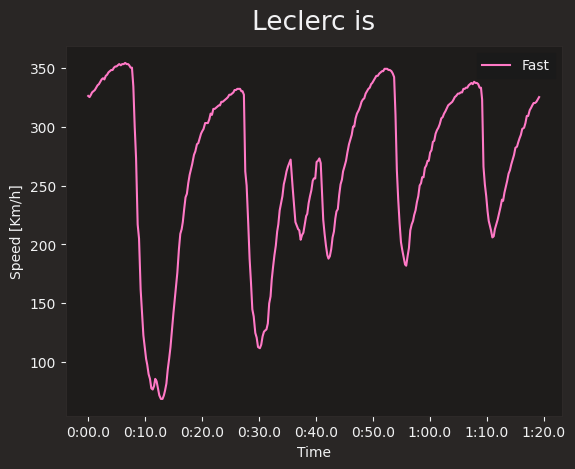

In [3]:
from matplotlib import pyplot as plt
import fastf1
import fastf1.plotting

fastf1.plotting.setup_mpl(color_scheme='fastf1')

session = fastf1.get_session(2019, 'Monza', 'Q')

session.load()
fast_leclerc = session.laps.pick_drivers('LEC').pick_fastest()
lec_car_data = fast_leclerc.get_car_data()
t = lec_car_data['Time']
vCar = lec_car_data['Speed']

# The rest is just plotting
fig, ax = plt.subplots()
ax.plot(t, vCar, label='Fast')
ax.set_xlabel('Time')
ax.set_ylabel('Speed [Km/h]')
ax.set_title('Leclerc is')
ax.legend()
plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from matplotlib.collections import LineCollection

import fastf1


session = fastf1.get_session(2025, 'Australian Grand Prix', 'Q')
session.load()

lap = session.laps.pick_fastest()
tel = lap.get_telemetry()

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            IN

In [10]:
x = np.array(tel['X'].values)
y = np.array(tel['Y'].values)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
gear = tel['nGear'].to_numpy().astype(float)

In [11]:
cmap = colormaps['Paired']
lc_comp = LineCollection(segments, norm=plt.Normalize(1, cmap.N+1), cmap=cmap)
lc_comp.set_array(gear)
lc_comp.set_linewidth(4)

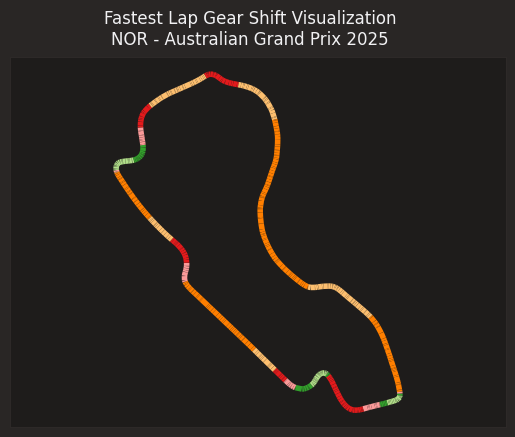

In [12]:
plt.gca().add_collection(lc_comp)
plt.axis('equal')
plt.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)


title = plt.suptitle(
    f"Fastest Lap Gear Shift Visualization\n"
    f"{lap['Driver']} - {session.event['EventName']} {session.event.year}"
)

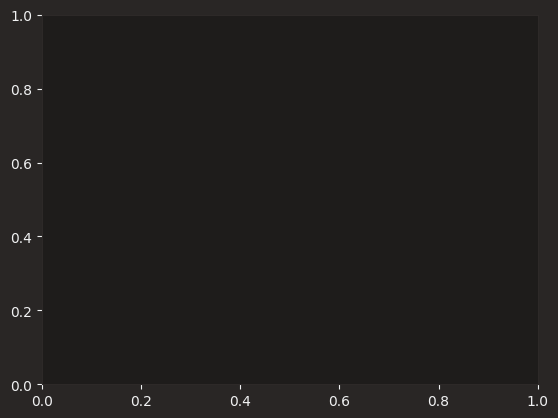

In [13]:
cbar = plt.colorbar(mappable=lc_comp, label="Gear",
                    boundaries=np.arange(1, 10))
cbar.set_ticks(np.arange(1.5, 9.5))
cbar.set_ticklabels(np.arange(1, 9))


plt.show()

In [14]:
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection

import fastf1 as ff1

In [15]:
year = 2021
wknd = 9
ses = 'R'
driver = 'RIC'
colormap = mpl.cm.plasma

In [16]:
session = ff1.get_session(year, wknd, ses)
weekend = session.event
session.load()
lap = session.laps.pick_drivers(driver).pick_fastest()

# Get telemetry data
x = lap.telemetry['X']              # values for x-axis
y = lap.telemetry['Y']              # values for y-axis
color = lap.telemetry['Speed']      # value to base color gradient on

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No c

In [17]:
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

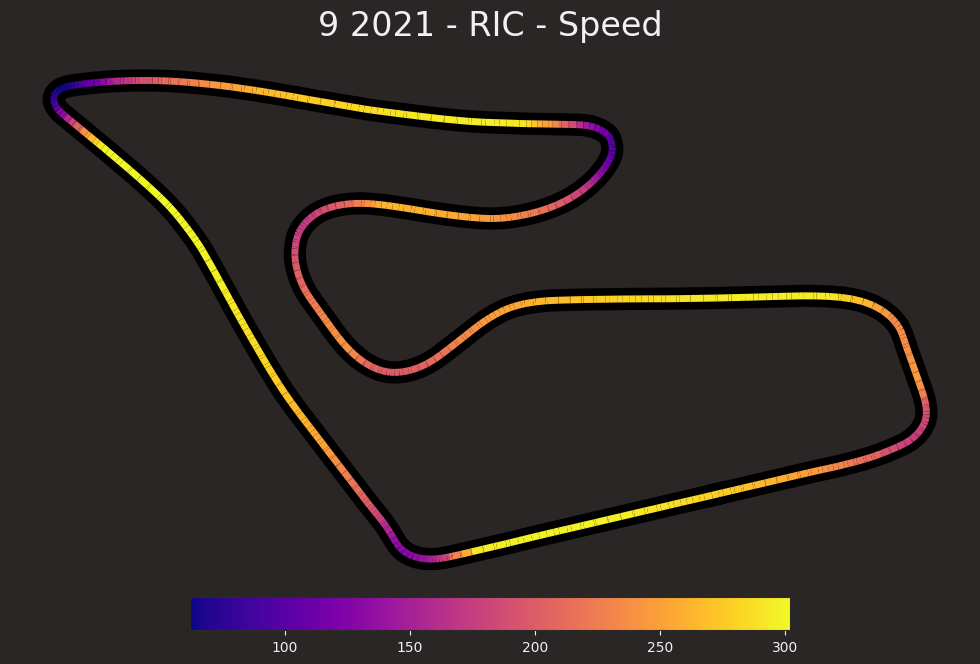

In [18]:
# We create a plot with title and adjust some setting to make it look good.
fig, ax = plt.subplots(sharex=True, sharey=True, figsize=(12, 6.75))
fig.suptitle(f'{weekend.name} {year} - {driver} - Speed', size=24, y=0.97)

# Adjust margins and turn of axis
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.12)
ax.axis('off')


# After this, we plot the data itself.
# Create background track line
ax.plot(lap.telemetry['X'], lap.telemetry['Y'],
        color='black', linestyle='-', linewidth=16, zorder=0)

# Create a continuous norm to map from data points to colors
norm = plt.Normalize(color.min(), color.max())
lc = LineCollection(segments, cmap=colormap, norm=norm,
                    linestyle='-', linewidth=5)

# Set the values used for colormapping
lc.set_array(color)

# Merge all line segments together
line = ax.add_collection(lc)


# Finally, we create a color bar as a legend.
cbaxes = fig.add_axes([0.25, 0.05, 0.5, 0.05])
normlegend = mpl.colors.Normalize(vmin=color.min(), vmax=color.max())
legend = mpl.colorbar.ColorbarBase(cbaxes, norm=normlegend, cmap=colormap,
                                   orientation="horizontal")


# Show the plot
plt.show()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Created cache directory: cache


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Lando Norris's Fastest Lap Time: 0 days 00:01:22.167000

Telemetry Data Sample:
                     Date            SessionTime DriverAhead  \
2 2025-03-16 05:34:04.038 0 days 02:26:41.419000               
3 2025-03-16 05:34:04.108 0 days 02:26:41.489000               
4 2025-03-16 05:34:04.242 0 days 02:26:41.623000               
5 2025-03-16 05:34:04.368 0 days 02:26:41.749000               
6 2025-03-16 05:34:04.482 0 days 02:26:41.863000               

   DistanceToDriverAhead                   Time           RPM       Speed  \
2                    NaN        0 days 00:00:00  11682.442865  292.271429   
3                    NaN 0 days 00:00:00.070000  11684.692861  292.521429   
4                    NaN 0 days 00:00:00.204000  11689.000000  293.000000   
5                    NaN 0 days 00:00:00.330000  11717.875029  294.050001   
6                    NaN 0 days 00:00:00.444000  11744.000000  295.000000   

   nGear  Throttle  Brake  DRS         Source   Distance  RelativeDistan

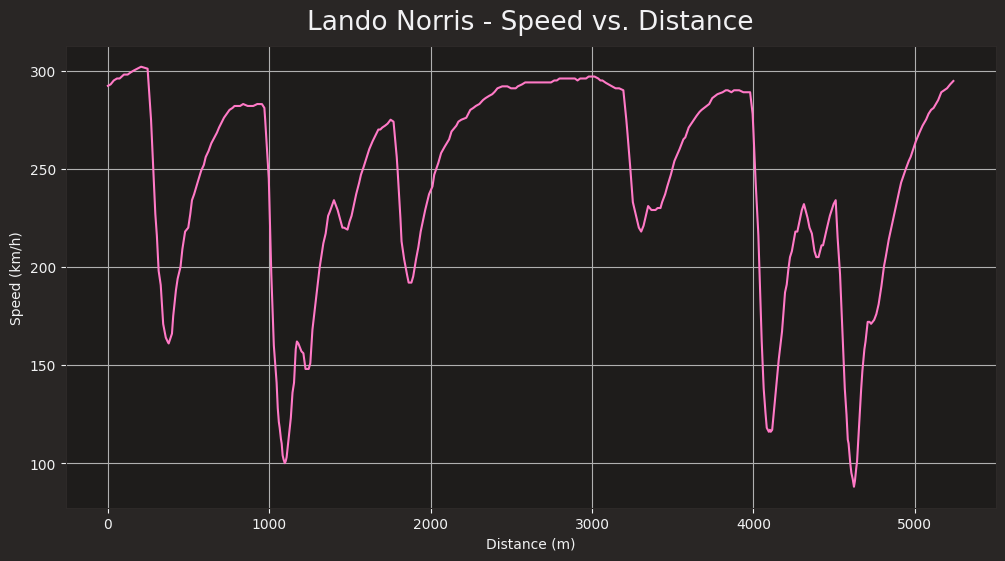

/opt/homebrew/lib/python3.11/site-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


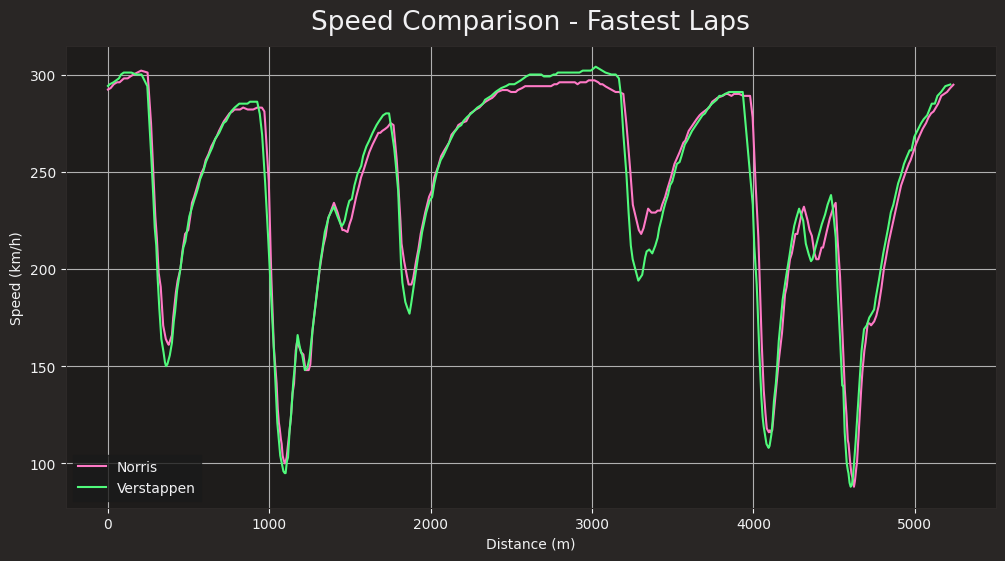

In [20]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create cache directory if it doesn't exist
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Created cache directory: {cache_dir}")

# Enable the cache
fastf1.Cache.enable_cache(cache_dir)

race = fastf1.get_session(2025, 'Australia', 'R')
race.load()

# Get Lando Norris's telemetry
norris_car_number = '4'  # Lando Norris's car number
norris = race.laps.pick_driver(norris_car_number)
norris_fastest_lap = norris.pick_fastest()
norris_telemetry = norris_fastest_lap.get_telemetry()

# Display basic telemetry information
print(f"Lando Norris's Fastest Lap Time: {norris_fastest_lap['LapTime']}")
print("\nTelemetry Data Sample:")
print(norris_telemetry.head())

# Create a simple visualization of speed vs. distance
plt.figure(figsize=(12, 6))
plt.plot(norris_telemetry['Distance'], norris_telemetry['Speed'])
plt.title("Lando Norris - Speed vs. Distance")
plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")
plt.grid(True)
plt.show()

# You can also compare with another driver if you want
# For example, with Max Verstappen
verstappen_car_number = '1'
verstappen = race.laps.pick_driver(verstappen_car_number)
verstappen_fastest_lap = verstappen.pick_fastest()
verstappen_telemetry = verstappen_fastest_lap.get_telemetry()

# Plot both drivers' speed for comparison
plt.figure(figsize=(12, 6))
plt.plot(norris_telemetry['Distance'], norris_telemetry['Speed'], label='Norris')
plt.plot(verstappen_telemetry['Distance'], verstappen_telemetry['Speed'], label='Verstappen')
plt.title("Speed Comparison - Fastest Laps")
plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from keplergl import KeplerGl


# Create cache directory if it doesn't exist
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Created cache directory: {cache_dir}")

# Enable the cache
fastf1.Cache.enable_cache(cache_dir)

race = fastf1.get_session(2025, 'Australia', 'R')
race.load()

# Get Lando Norris's telemetry
norris_car_number = '4'  # Lando Norris's car number
norris = race.laps.pick_driver(norris_car_number)
norris_fastest_lap = norris.pick_fastest()
norris_telemetry = norris_fastest_lap.get_telemetry()

# Get Max Verstappen's telemetry for comparison
verstappen_car_number = '1'
verstappen = race.laps.pick_driver(verstappen_car_number)
verstappen_fastest_lap = verstappen.pick_fastest()
verstappen_telemetry = verstappen_fastest_lap.get_telemetry()

# Make sure we have position data (X, Y coordinates)
# Convert to DataFrame if it's not already
norris_df = pd.DataFrame(norris_telemetry)
verstappen_df = pd.DataFrame(verstappen_telemetry)

# Check if 'X' and 'Y' columns exist (these are the position coordinates)
if 'X' in norris_df.columns and 'Y' in norris_df.columns:
    # Add driver identification column
    norris_df['Driver'] = 'Norris'
    verstappen_df['Driver'] = 'Verstappen'
    
    # Combine the data
    combined_df = pd.concat([norris_df, verstappen_df])
    
    # Create a Kepler.gl map
    map_1 = KeplerGl(height=600)
    
    # Add data to the map
    map_1.add_data(data=combined_df, name='F1 Telemetry')
    
    # Display the map
    display(map_1)
else:
    # If position data is not available, we need to work with GPS data
    # Some fastf1 versions provide direct lat/lon data
    if 'SessionTime' in norris_df.columns and hasattr(race, 'gps_data'):
        # Get GPS data
        gps_data = race.gps_data
        
        # Merge GPS data with telemetry based on SessionTime
        norris_df = pd.merge_asof(
            norris_df.sort_values('SessionTime'), 
            gps_data[gps_data['Driver'] == norris_car_number][['SessionTime', 'Lat', 'Lon']].sort_values('SessionTime'),
            on='SessionTime'
        )
        
        verstappen_df = pd.merge_asof(
            verstappen_df.sort_values('SessionTime'), 
            gps_data[gps_data['Driver'] == verstappen_car_number][['SessionTime', 'Lat', 'Lon']].sort_values('SessionTime'),
            on='SessionTime'
        )
        
        # Add driver identification column
        norris_df['Driver'] = 'Norris'
        verstappen_df['Driver'] = 'Verstappen'
        
        # Combine the data
        combined_df = pd.concat([norris_df, verstappen_df])
        
        # Create a Kepler.gl map
        map_1 = KeplerGl(height=600)
        
        # Add data to the map
        map_1.add_data(data=combined_df, name='F1 Telemetry')
        
        # Display the map
        display(map_1)
    else:
        print("Position data (X, Y) or GPS data not available in the telemetry.")
        print("Available columns:", norris_df.columns.tolist())
        
        # We can try to get the track map as a reference
        try:
            circuit_info = race.get_circuit_info()
            if circuit_info is not None and hasattr(circuit_info, 'to_dataframe'):
                circuit_df = circuit_info.to_dataframe()
                print("Circuit data available:", circuit_df.head())
                
                # Create a Kepler.gl map with just the circuit
                map_1 = KeplerGl(height=600)
                map_1.add_data(data=circuit_df, name='Circuit')
                display(map_1)
            else:
                print("Circuit information not available in the expected format.")
        except Exception as e:
            print(f"Error getting circuit information: {e}")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


/opt/homebrew/lib/python3.11/site-packages/jupyter_client/session.py:718: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


KeplerGl(data={'F1 Telemetry': {'index': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, …

In [24]:
norris_df.head()

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z,Driver
2,2025-03-16 05:34:04.038,0 days 02:26:41.419000,,NaN,0 days 00:00:00,11682.442865,292.271429,7,99.0,False,1,interpolation,0.003740,7.132979e-07,OnTrack,-1206.077830,-1323.094438,85.211547,Norris
3,2025-03-16 05:34:04.108,0 days 02:26:41.489000,,NaN,0 days 00:00:00.070000,11684.692861,292.521429,7,99.0,False,1,pos,5.696356,1.086479e-03,OnTrack,-1244.000000,-1287.000000,85.000000,Norris
4,2025-03-16 05:34:04.242,0 days 02:26:41.623000,,NaN,0 days 00:00:00.204000,11689.000000,293.000000,7,99.0,False,1,car,16.624444,3.170819e-03,OnTrack,-1300.353338,-1233.493190,84.556317,Norris
5,2025-03-16 05:34:04.368,0 days 02:26:41.749000,,NaN,0 days 00:00:00.330000,11717.875029,294.050001,7,99.0,False,1,pos,26.936930,5.137743e-03,OnTrack,-1363.000000,-1174.000000,84.000000,Norris
6,2025-03-16 05:34:04.482,0 days 02:26:41.863000,,NaN,0 days 00:00:00.444000,11744.000000,295.000000,7,99.0,False,1,car,36.291111,6.921888e-03,OnTrack,-1451.350038,-1089.921513,83.305341,Norris


In [25]:
norris_df.columns

Index(['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time',
       'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z', 'Driver'],
      dtype='object')

In [27]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from keplergl import KeplerGl
from fastf1 import plotting
from matplotlib import cm
from matplotlib.colors import Normalize

# Create cache directory if it doesn't exist
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Created cache directory: {cache_dir}")

# Enable the cache
fastf1.Cache.enable_cache(cache_dir)

# Print fastf1 version for debugging
print(f"FastF1 version: {fastf1.__version__}")

# Load the session
race = fastf1.get_session(2025, 'Australia', 'R')
race.load()

# Try different approaches to get circuit info
try:
    # For newer fastf1 versions
    circuit_info = race.get_circuit_info()
    print("Circuit info available:", circuit_info is not None)
except Exception as e:
    print(f"Error getting circuit info with get_circuit_info(): {e}")
    circuit_info = None

# Try alternative method to get track data
try:
    # For some fastf1 versions
    track_data = race.track
    print("Track data available:", track_data is not None)
except Exception as e:
    print(f"Error getting track data with race.track: {e}")
    track_data = None

# Get Lando Norris's telemetry
norris_car_number = '4'  # Lando Norris's car number
norris = race.laps.pick_driver(norris_car_number)
norris_fastest_lap = norris.pick_fastest()
norris_telemetry = norris_fastest_lap.get_telemetry()

# Get Max Verstappen's telemetry for comparison
verstappen_car_number = '1'
verstappen = race.laps.pick_driver(verstappen_car_number)
verstappen_fastest_lap = verstappen.pick_fastest()
verstappen_telemetry = verstappen_fastest_lap.get_telemetry()

# Convert to DataFrame if it's not already
norris_df = pd.DataFrame(norris_telemetry)
verstappen_df = pd.DataFrame(verstappen_telemetry)

print("\nAvailable columns in telemetry data:")
print(norris_df.columns.tolist())

# For Kepler.gl visualization, we need coordinate data
# Since direct GPS conversion might not be possible, let's use the X, Y coordinates
# as they still represent the spatial position on the track

# Add driver identification and additional useful columns
norris_df['Driver'] = 'Norris'
norris_df['SpeedCategory'] = pd.cut(norris_df['Speed'], bins=5, labels=["Very Slow", "Slow", "Medium", "Fast", "Very Fast"])
norris_df['BrakeCategory'] = pd.cut(norris_df['Brake'], bins=[0, 0.1, 0.5, 1.0], labels=["No Brake", "Light Brake", "Heavy Brake"])
norris_df['ThrottleCategory'] = pd.cut(norris_df['Throttle'], bins=[0, 0.1, 0.5, 1.0], labels=["No Throttle", "Partial Throttle", "Full Throttle"])

verstappen_df['Driver'] = 'Verstappen'
verstappen_df['SpeedCategory'] = pd.cut(verstappen_df['Speed'], bins=5, labels=["Very Slow", "Slow", "Medium", "Fast", "Very Fast"])
verstappen_df['BrakeCategory'] = pd.cut(verstappen_df['Brake'], bins=[0, 0.1, 0.5, 1.0], labels=["No Brake", "Light Brake", "Heavy Brake"])
verstappen_df['ThrottleCategory'] = pd.cut(verstappen_df['Throttle'], bins=[0, 0.1, 0.5, 1.0], labels=["No Throttle", "Partial Throttle", "Full Throttle"])

# For Kepler.gl to properly display the data, we need latitude and longitude
# Since we don't have actual GPS data, we'll use the X, Y coordinates as a substitute
# We just need to rename/map them to what Kepler expects

# Scale the X,Y values to make them look more like lat/lon for visualization
# This is just for visualization purposes, not actual GPS coordinates
x_min, x_max = min(norris_df['X'].min(), verstappen_df['X'].min()), max(norris_df['X'].max(), verstappen_df['X'].max())
y_min, y_max = min(norris_df['Y'].min(), verstappen_df['Y'].min()), max(norris_df['Y'].max(), verstappen_df['Y'].max())

# Center around a fake "Melbourne" coordinate to make it look natural on the map
melbourne_lat, melbourne_lon = -37.840935, 144.946457
scale_factor = 0.01  # Adjust this to change the size on the map

norris_df['latitude'] = melbourne_lat + (norris_df['Y'] - y_min) / (y_max - y_min) * scale_factor
norris_df['longitude'] = melbourne_lon + (norris_df['X'] - x_min) / (x_max - x_min) * scale_factor

verstappen_df['latitude'] = melbourne_lat + (verstappen_df['Y'] - y_min) / (y_max - y_min) * scale_factor
verstappen_df['longitude'] = melbourne_lon + (verstappen_df['X'] - x_min) / (x_max - x_min) * scale_factor

# Combine the data
combined_df = pd.concat([norris_df, verstappen_df])

# Show sample of the data
print("\nPrepared data for visualization:")
print(combined_df[['Driver', 'Speed', 'latitude', 'longitude', 'SpeedCategory']].head())

# Create a Kepler.gl map
map_1 = KeplerGl(height=600)

# Add data to the map
map_1.add_data(data=combined_df, name='F1 Telemetry')

# Display the map
display(map_1)

print("\nKepler.gl Map Instructions:")
print("1. In the Kepler interface, click on 'Add Layer'")
print("2. Select 'Point' or 'Line' for the layer type")
print("3. For 'Columns' select 'latitude' for latitude and 'longitude' for longitude")
print("4. In the 'Color' section, choose 'Speed', 'SpeedCategory', or 'Driver' to color points")
print("5. You can also try visualizing 'Throttle', 'Brake', or 'RPM' values")
print("6. For Line layers, set 'Sort' to 'SessionTime' to connect points in the correct order")
print("\nNote: The coordinates are scaled X,Y values centered around Melbourne, not actual GPS coordinates")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


FastF1 version: 3.6.1


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']


Circuit info available: True
Error getting track data with race.track: 'Session' object has no attribute 'track'

Available columns in telemetry data:
['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']

Prepared data for visualization:
   Driver       Speed   latitude   longitude SpeedCategory
2  Norris  292.271429 -37.838500  144.950538     Very Fast
3  Norris  292.521429 -37.838479  144.950512     Very Fast
4  Norris  293.000000 -37.838449  144.950474     Very Fast
5  Norris  294.050001 -37.838414  144.950431     Very Fast
6  Norris  295.000000 -37.838366  144.950371     Very Fast
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


/opt/homebrew/lib/python3.11/site-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/homebrew/lib/python3.11/site-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/homebrew/lib/python3.11/site-packages/jupyter_client/session.py:718: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


KeplerGl(data={'F1 Telemetry': {'index': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, …


Kepler.gl Map Instructions:
1. In the Kepler interface, click on 'Add Layer'
2. Select 'Point' or 'Line' for the layer type
3. For 'Columns' select 'latitude' for latitude and 'longitude' for longitude
4. In the 'Color' section, choose 'Speed', 'SpeedCategory', or 'Driver' to color points
5. You can also try visualizing 'Throttle', 'Brake', or 'RPM' values
6. For Line layers, set 'Sort' to 'SessionTime' to connect points in the correct order

Note: The coordinates are scaled X,Y values centered around Melbourne, not actual GPS coordinates


In [28]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from keplergl import KeplerGl

# Create cache directory if it doesn't exist
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Created cache directory: {cache_dir}")

# Enable the cache
fastf1.Cache.enable_cache(cache_dir)

# Print fastf1 version for debugging
print(f"FastF1 version: {fastf1.__version__}")

# Load the session
race = fastf1.get_session(2025, 'Australia', 'R')
race.load()

# Explore the available methods and properties to find circuit data
print("\nAvailable race session attributes:")
for attr in dir(race):
    if not attr.startswith('_'):  # Skip private attributes
        print(attr)

# Try to get circuit information
try:
    print("\nExploring circuit info...")
    # Get the event information
    event = race.event
    print("Event info available:", event is not None)
    if event is not None:
        print("Event attributes:", [attr for attr in dir(event) if not attr.startswith('_')])
        
        # Check if we have circuit info
        if hasattr(event, 'Circuit'):
            circuit = event.Circuit
            print("\nCircuit info available:", circuit is not None)
            if circuit is not None:
                print("Circuit attributes:", [attr for attr in dir(circuit) if not attr.startswith('_')])
                
                # Try to get circuit location
                if hasattr(circuit, 'Location'):
                    location = circuit.Location
                    print("\nLocation info:", location)
                    if hasattr(location, 'lat') and hasattr(location, 'long'):
                        circuit_lat = float(location.lat)
                        circuit_lon = float(location.long)
                        print(f"Circuit coordinates: Lat {circuit_lat}, Lon {circuit_lon}")
                    else:
                        print("Location object doesn't have lat/long attributes")
                else:
                    print("Circuit doesn't have Location attribute")
        else:
            print("Event doesn't have Circuit attribute")
except Exception as e:
    print(f"Error exploring circuit info: {e}")

# Alternative approach: try to directly access circuit information
try:
    circuit_info = race.get_circuit_info()
    print("\nCircuit info from get_circuit_info():", circuit_info is not None)
    if circuit_info is not None:
        print("Circuit info type:", type(circuit_info))
        # Try to access attributes/methods
        for attr in dir(circuit_info):
            if not attr.startswith('_'):
                print(attr)
except Exception as e:
    print(f"Error with get_circuit_info(): {e}")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


FastF1 version: 3.6.1


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']



Available race session attributes:
api_path
car_data
date
drivers
event
f1_api_support
get_circuit_info
get_driver
laps
load
name
pos_data
race_control_messages
results
session_info
session_start_time
session_status
t0_date
total_laps
track_status
weather_data

Exploring circuit info...
Event info available: True
Event attributes: ['Country', 'EventDate', 'EventFormat', 'EventName', 'F1ApiSupport', 'Location', 'OfficialEventName', 'RoundNumber', 'Session1', 'Session1Date', 'Session1DateUtc', 'Session2', 'Session2Date', 'Session2DateUtc', 'Session3', 'Session3Date', 'Session3DateUtc', 'Session4', 'Session4Date', 'Session4DateUtc', 'Session5', 'Session5Date', 'Session5DateUtc', 'T', 'abs', 'add', 'add_prefix', 'add_suffix', 'agg', 'aggregate', 'align', 'all', 'any', 'apply', 'argmax', 'argmin', 'argsort', 'array', 'asfreq', 'asof', 'astype', 'at', 'at_time', 'attrs', 'autocorr', 'axes', 'backfill', 'between', 'between_time', 'bfill', 'bool', 'case_when', 'clip', 'combine', 'combine_firs

In [35]:
import fastf1
import pandas as pd
import numpy as np
from keplergl import KeplerGl

# Enable FastF1 cache to speed up data loading
fastf1.Cache.enable_cache('cache')

# Load the 2025 Australian Grand Prix session
session = fastf1.get_session(2025, 'Australia', 'R')
session.load()

# Get Lando Norris's laps (car number 4)
lando_laps = session.laps.pick_driver('NOR')

# Get the fastest lap
fastest_lap = lando_laps.pick_fastest()

# Get telemetry data with position
telemetry = fastest_lap.get_pos_data()

# Albert Park Circuit GPS coordinates (actual track reference points)
# These are precise coordinates from the actual circuit
# Reference: Start/Finish line at Albert Park
REFERENCE_LAT = -37.84694  # Latitude of start/finish
REFERENCE_LON = 144.96806  # Longitude of start/finish

# The track rotation angle from FastF1 circuit info
try:
    circuit_info = session.get_circuit_info()
    track_angle = np.radians(circuit_info.rotation)
except:
    # Albert Park specific rotation if circuit_info fails
    track_angle = np.radians(38)

# FastF1 X/Y coordinates are in meters, we need to:
# 1. Apply track rotation to align with geographic north
# 2. Convert meters to degrees lat/lon

# Rotation matrix (rotate by negative angle to align with north)
cos_angle = np.cos(-track_angle)
sin_angle = np.sin(-track_angle)

# Apply rotation
x_rotated = telemetry['X'] * cos_angle - telemetry['Y'] * sin_angle
y_rotated = telemetry['X'] * sin_angle + telemetry['Y'] * cos_angle

# Melbourne latitude: ~-37.85°
# Conversion factors (meters per degree)
METERS_PER_DEG_LAT = 111320  # Constant
METERS_PER_DEG_LON = 111320 * np.cos(np.radians(REFERENCE_LAT))  # Varies with latitude

# Convert to lat/lon offset from reference point
lat_offset = y_rotated / METERS_PER_DEG_LAT
lon_offset = x_rotated / METERS_PER_DEG_LON

# Apply offsets to reference coordinates
telemetry['Latitude'] = REFERENCE_LAT + lat_offset
telemetry['Longitude'] = REFERENCE_LON + lon_offset

# Get full telemetry for speed/throttle/brake data
tel_full = fastest_lap.get_telemetry()
tel_full = tel_full.add_distance()

# Helper function to convert time to seconds
def to_seconds(time_series):
    if hasattr(time_series.iloc[0], 'total_seconds'):
        return time_series.dt.total_seconds()
    else:
        return time_series.values

# Get time arrays
telemetry_time = to_seconds(telemetry['SessionTime'])
tel_full_time = to_seconds(tel_full['SessionTime'])

# Interpolate telemetry data to position data timestamps
kepler_data = pd.DataFrame({
    'Latitude': telemetry['Latitude'],
    'Longitude': telemetry['Longitude'],
    'Speed': np.interp(telemetry_time, tel_full_time, tel_full['Speed']),
    'Throttle': np.interp(telemetry_time, tel_full_time, tel_full['Throttle']),
    'Brake': np.interp(telemetry_time, tel_full_time, tel_full['Brake']),
    'Gear': np.interp(telemetry_time, tel_full_time, tel_full['nGear']),
    'RPM': np.interp(telemetry_time, tel_full_time, tel_full['RPM']),
    'Time': telemetry_time
})

# Remove any NaN values
kepler_data = kepler_data.dropna()

# Create Kepler map
map_1 = KeplerGl(height=800)

# Add the data
map_1.add_data(data=kepler_data, name='Lando Norris - 2025 Australian GP')

# Configure the map centered on the track
config = {
    'version': 'v1',
    'config': {
        'mapState': {
            'latitude': kepler_data['Latitude'].mean(),
            'longitude': kepler_data['Longitude'].mean(),
            'zoom': 14.5
        }
    }
}

map_1.config = config

# Save the map to HTML
# map_1.save_to_html(file_name='lando_norris_australia_2025.html')
display(map_1)

print(f"Data points: {len(kepler_data)}")
print(f"Lap time: {fastest_lap['LapTime']}")
print(f"Latitude range: {kepler_data['Latitude'].min():.6f} to {kepler_data['Latitude'].max():.6f}")
print(f"Longitude range: {kepler_data['Longitude'].min():.6f} to {kepler_data['Longitude'].max():.6f}")
print(f"Average speed: {kepler_data['Speed'].mean():.2f} km/h")
print(f"Max speed: {kepler_data['Speed'].max():.2f} km/h")
print(f"\nTrack center: {kepler_data['Latitude'].mean():.6f}, {kepler_data['Longitude'].mean():.6f}")
print("\nMap saved to: lando_norris_australia_2025.html")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(config={'version': 'v1', 'config': {'mapState': {'latitude': -37.83209490945217, 'longitude': 144.987…

Data points: 322
Lap time: 0 days 00:01:22.167000
Latitude range: -37.925373 to -37.746906
Longitude range: 144.946297 to 145.055849
Average speed: 229.92 km/h
Max speed: 301.82 km/h

Track center: -37.832095, 144.987586

Map saved to: lando_norris_australia_2025.html


In [36]:
circuit_geojson = {
"type": "FeatureCollection",
"name": "au-1953",
"bbox": [ 144.962138, -37.853926, 144.978590, -37.838005 ],                                                                        
"features": [
{ "type": "Feature", "properties": { "id": "au-1953", "Location": "Melbourne", "Name": "Albert Park Circuit", "opened": 1953, "firstgp": 1996, "length": 5278, "altitude": 10 }, "bbox": [ 144.962138, -37.853926, 144.97859, -37.838005 ], "geometry": { "type": "LineString", "coordinates": [ [ 144.968644, -37.849757 ], [ 144.967627, -37.848964 ], [ 144.966121, -37.847751 ], [ 144.966034, -37.847681 ], [ 144.965997, -37.847585 ], [ 144.966003, -37.847543 ], [ 144.966028, -37.847504 ], [ 144.966079, -37.847406 ], [ 144.966164, -37.847287 ], [ 144.966217, -37.847135 ], [ 144.966247, -37.846948 ], [ 144.966253, -37.846811 ], [ 144.9662, -37.846544 ], [ 144.966134, -37.846408 ], [ 144.966031, -37.846266 ], [ 144.96591, -37.846152 ], [ 144.965642, -37.845941 ], [ 144.965324, -37.845711 ], [ 144.964876, -37.845369 ], [ 144.96433, -37.844909 ], [ 144.964111, -37.844724 ], [ 144.963529, -37.844147 ], [ 144.96324, -37.843842 ], [ 144.962941, -37.843471 ], [ 144.962366, -37.842676 ], [ 144.962224, -37.842453 ], [ 144.962138, -37.842286 ], [ 144.962149, -37.842193 ], [ 144.962198, -37.842127 ], [ 144.962319, -37.842079 ], [ 144.962725, -37.842023 ], [ 144.963493, -37.841899 ], [ 144.963582, -37.841871 ], [ 144.963638, -37.841842 ], [ 144.963676, -37.8418 ], [ 144.963732, -37.841669 ], [ 144.963743, -37.841531 ], [ 144.963691, -37.840347 ], [ 144.963673, -37.839913 ], [ 144.963686, -37.839876 ], [ 144.963849, -37.839726 ], [ 144.963998, -37.839637 ], [ 144.96514, -37.838986 ], [ 144.965393, -37.838871 ], [ 144.966572, -37.838491 ], [ 144.967017, -37.838364 ], [ 144.96742, -37.838172 ], [ 144.967726, -37.838025 ], [ 144.967863, -37.838006 ], [ 144.967972, -37.838005 ], [ 144.968073, -37.838052 ], [ 144.968206, -37.838176 ], [ 144.968367, -37.838288 ], [ 144.968587, -37.838411 ], [ 144.968867, -37.838494 ], [ 144.96923, -37.838529 ], [ 144.969558, -37.838541 ], [ 144.969836, -37.838574 ], [ 144.970146, -37.838659 ], [ 144.97042, -37.838762 ], [ 144.970722, -37.838939 ], [ 144.970926, -37.839083 ], [ 144.971129, -37.839292 ], [ 144.971319, -37.839552 ], [ 144.971426, -37.839817 ], [ 144.971493, -37.840022 ], [ 144.971527, -37.840194 ], [ 144.971803, -37.841385 ], [ 144.971805, -37.841534 ], [ 144.971775, -37.841713 ], [ 144.971701, -37.841896 ], [ 144.971614, -37.842052 ], [ 144.971459, -37.842226 ], [ 144.971316, -37.842364 ], [ 144.971159, -37.842532 ], [ 144.97108, -37.842654 ], [ 144.971011, -37.842792 ], [ 144.970959, -37.842949 ], [ 144.970646, -37.84426 ], [ 144.970622, -37.84442 ], [ 144.970609, -37.84461 ], [ 144.970609, -37.844784 ], [ 144.970628, -37.8451 ], [ 144.970674, -37.845345 ], [ 144.970759, -37.845626 ], [ 144.970864, -37.845898 ], [ 144.971, -37.846132 ], [ 144.971142, -37.846349 ], [ 144.971378, -37.846641 ], [ 144.971536, -37.846825 ], [ 144.971852, -37.84709 ], [ 144.972897, -37.847824 ], [ 144.973062, -37.847925 ], [ 144.973217, -37.847992 ], [ 144.973331, -37.848035 ], [ 144.973552, -37.848088 ], [ 144.973764, -37.848102 ], [ 144.974022, -37.848094 ], [ 144.974255, -37.848093 ], [ 144.974481, -37.848086 ], [ 144.974673, -37.848091 ], [ 144.974837, -37.848123 ], [ 144.975001, -37.848186 ], [ 144.975113, -37.848236 ], [ 144.975312, -37.848376 ], [ 144.976467, -37.849153 ], [ 144.976897, -37.849437 ], [ 144.977107, -37.849636 ], [ 144.977263, -37.849779 ], [ 144.977433, -37.849992 ], [ 144.977605, -37.850308 ], [ 144.977777, -37.850704 ], [ 144.978233, -37.85195 ], [ 144.978506, -37.852742 ], [ 144.978558, -37.852962 ], [ 144.978587, -37.853073 ], [ 144.97859, -37.853141 ], [ 144.978518, -37.853171 ], [ 144.978304, -37.853236 ], [ 144.977276, -37.853564 ], [ 144.976217, -37.853897 ], [ 144.976135, -37.853915 ], [ 144.976003, -37.853926 ], [ 144.975842, -37.853917 ], [ 144.975676, -37.853863 ], [ 144.975508, -37.853774 ], [ 144.975409, -37.853702 ], [ 144.975314, -37.853585 ], [ 144.974686, -37.85267 ], [ 144.974306, -37.852184 ], [ 144.974255, -37.852119 ], [ 144.974202, -37.852081 ], [ 144.974149, -37.852065 ], [ 144.974058, -37.852062 ], [ 144.973994, -37.852091 ], [ 144.973312, -37.852701 ], [ 144.973217, -37.852776 ], [ 144.973115, -37.852823 ], [ 144.972987, -37.852863 ], [ 144.972873, -37.852884 ], [ 144.972771, -37.852883 ], [ 144.972649, -37.852864 ], [ 144.97248, -37.852817 ], [ 144.972355, -37.852747 ], [ 144.972306, -37.852709 ], [ 144.968644, -37.849757 ] ] } }
]
}

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

Calculating coordinate transformation...
Transformation found:
  Translation: (0.00, 0.00) meters
  Rotation: 0.02 degrees
  Scale: 0.0061
  Error: 41.97 meters
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'Lando Norris - 2025 Australian GP': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1…


Data points: 322
Lap time: 0 days 00:01:22.167000
Average speed: 229.92 km/h
Max speed: 301.82 km/h

Map saved to: lando_norris_australia_2025.html


In [38]:
circuit_geojson = {
"type": "FeatureCollection",
"name": "au-1953",
"bbox": [ 144.962138, -37.853926, 144.978590, -37.838005 ],
"features": [
{ "type": "Feature", "properties": { "id": "au-1953", "Location": "Melbourne", "Name": "Albert Park Circuit", "opened": 1953, "firstgp": 1996, "length": 5278, "altitude": 10 }, "bbox": [ 144.962138, -37.853926, 144.97859, -37.838005 ], "geometry": { "type": "LineString", "coordinates": [ [ 144.968644, -37.849757 ], [ 144.967627, -37.848964 ], [ 144.966121, -37.847751 ], [ 144.966034, -37.847681 ], [ 144.965997, -37.847585 ], [ 144.966003, -37.847543 ], [ 144.966028, -37.847504 ], [ 144.966079, -37.847406 ], [ 144.966164, -37.847287 ], [ 144.966217, -37.847135 ], [ 144.966247, -37.846948 ], [ 144.966253, -37.846811 ], [ 144.9662, -37.846544 ], [ 144.966134, -37.846408 ], [ 144.966031, -37.846266 ], [ 144.96591, -37.846152 ], [ 144.965642, -37.845941 ], [ 144.965324, -37.845711 ], [ 144.964876, -37.845369 ], [ 144.96433, -37.844909 ], [ 144.964111, -37.844724 ], [ 144.963529, -37.844147 ], [ 144.96324, -37.843842 ], [ 144.962941, -37.843471 ], [ 144.962366, -37.842676 ], [ 144.962224, -37.842453 ], [ 144.962138, -37.842286 ], [ 144.962149, -37.842193 ], [ 144.962198, -37.842127 ], [ 144.962319, -37.842079 ], [ 144.962725, -37.842023 ], [ 144.963493, -37.841899 ], [ 144.963582, -37.841871 ], [ 144.963638, -37.841842 ], [ 144.963676, -37.8418 ], [ 144.963732, -37.841669 ], [ 144.963743, -37.841531 ], [ 144.963691, -37.840347 ], [ 144.963673, -37.839913 ], [ 144.963686, -37.839876 ], [ 144.963849, -37.839726 ], [ 144.963998, -37.839637 ], [ 144.96514, -37.838986 ], [ 144.965393, -37.838871 ], [ 144.966572, -37.838491 ], [ 144.967017, -37.838364 ], [ 144.96742, -37.838172 ], [ 144.967726, -37.838025 ], [ 144.967863, -37.838006 ], [ 144.967972, -37.838005 ], [ 144.968073, -37.838052 ], [ 144.968206, -37.838176 ], [ 144.968367, -37.838288 ], [ 144.968587, -37.838411 ], [ 144.968867, -37.838494 ], [ 144.96923, -37.838529 ], [ 144.969558, -37.838541 ], [ 144.969836, -37.838574 ], [ 144.970146, -37.838659 ], [ 144.97042, -37.838762 ], [ 144.970722, -37.838939 ], [ 144.970926, -37.839083 ], [ 144.971129, -37.839292 ], [ 144.971319, -37.839552 ], [ 144.971426, -37.839817 ], [ 144.971493, -37.840022 ], [ 144.971527, -37.840194 ], [ 144.971803, -37.841385 ], [ 144.971805, -37.841534 ], [ 144.971775, -37.841713 ], [ 144.971701, -37.841896 ], [ 144.971614, -37.842052 ], [ 144.971459, -37.842226 ], [ 144.971316, -37.842364 ], [ 144.971159, -37.842532 ], [ 144.97108, -37.842654 ], [ 144.971011, -37.842792 ], [ 144.970959, -37.842949 ], [ 144.970646, -37.84426 ], [ 144.970622, -37.84442 ], [ 144.970609, -37.84461 ], [ 144.970609, -37.844784 ], [ 144.970628, -37.8451 ], [ 144.970674, -37.845345 ], [ 144.970759, -37.845626 ], [ 144.970864, -37.845898 ], [ 144.971, -37.846132 ], [ 144.971142, -37.846349 ], [ 144.971378, -37.846641 ], [ 144.971536, -37.846825 ], [ 144.971852, -37.84709 ], [ 144.972897, -37.847824 ], [ 144.973062, -37.847925 ], [ 144.973217, -37.847992 ], [ 144.973331, -37.848035 ], [ 144.973552, -37.848088 ], [ 144.973764, -37.848102 ], [ 144.974022, -37.848094 ], [ 144.974255, -37.848093 ], [ 144.974481, -37.848086 ], [ 144.974673, -37.848091 ], [ 144.974837, -37.848123 ], [ 144.975001, -37.848186 ], [ 144.975113, -37.848236 ], [ 144.975312, -37.848376 ], [ 144.976467, -37.849153 ], [ 144.976897, -37.849437 ], [ 144.977107, -37.849636 ], [ 144.977263, -37.849779 ], [ 144.977433, -37.849992 ], [ 144.977605, -37.850308 ], [ 144.977777, -37.850704 ], [ 144.978233, -37.85195 ], [ 144.978506, -37.852742 ], [ 144.978558, -37.852962 ], [ 144.978587, -37.853073 ], [ 144.97859, -37.853141 ], [ 144.978518, -37.853171 ], [ 144.978304, -37.853236 ], [ 144.977276, -37.853564 ], [ 144.976217, -37.853897 ], [ 144.976135, -37.853915 ], [ 144.976003, -37.853926 ], [ 144.975842, -37.853917 ], [ 144.975676, -37.853863 ], [ 144.975508, -37.853774 ], [ 144.975409, -37.853702 ], [ 144.975314, -37.853585 ], [ 144.974686, -37.85267 ], [ 144.974306, -37.852184 ], [ 144.974255, -37.852119 ], [ 144.974202, -37.852081 ], [ 144.974149, -37.852065 ], [ 144.974058, -37.852062 ], [ 144.973994, -37.852091 ], [ 144.973312, -37.852701 ], [ 144.973217, -37.852776 ], [ 144.973115, -37.852823 ], [ 144.972987, -37.852863 ], [ 144.972873, -37.852884 ], [ 144.972771, -37.852883 ], [ 144.972649, -37.852864 ], [ 144.97248, -37.852817 ], [ 144.972355, -37.852747 ], [ 144.972306, -37.852709 ], [ 144.968644, -37.849757 ] ] } }
]
}

In [42]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from keplergl import KeplerGl
from shapely.geometry import LineString, Point
import math
import ujson as json

# Create cache directory if it doesn't exist
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Created cache directory: {cache_dir}")

# Enable the cache
fastf1.Cache.enable_cache(cache_dir)

# Print fastf1 version for debugging
print(f"FastF1 version: {fastf1.__version__}")

# Load the session
race = fastf1.get_session(2023, 'Australia', 'R')
race.load()

# Get Lando Norris's telemetry
norris_car_number = '4'  # Lando Norris's car number
norris = race.laps.pick_driver(norris_car_number)
norris_fastest_lap = norris.pick_fastest()
norris_telemetry = norris_fastest_lap.get_telemetry()

# Get Max Verstappen's telemetry for comparison
verstappen_car_number = '1'
verstappen = race.laps.pick_driver(verstappen_car_number)
verstappen_fastest_lap = verstappen.pick_fastest()
verstappen_telemetry = verstappen_fastest_lap.get_telemetry()

# Convert to DataFrames
norris_df = pd.DataFrame(norris_telemetry)
verstappen_df = pd.DataFrame(verstappen_telemetry)

print("Available columns in telemetry data:")
print(norris_df.columns.tolist())

# Extract the circuit coordinates from the GeoJSON
circuit_coords = circuit_geojson['features'][0]['geometry']['coordinates']

# Get bounding box of the circuit
circuit_bbox = circuit_geojson['bbox']
lon_min, lat_min, lon_max, lat_max = circuit_bbox
circuit_center_lon = (lon_min + lon_max) / 2
circuit_center_lat = (lat_min + lat_max) / 2
print(f"Circuit center from GeoJSON: Lat {circuit_center_lat}, Lon {circuit_center_lon}")

# Extract X and Y from telemetry data
telemetry_x_norris = norris_df['X'].values
telemetry_y_norris = norris_df['Y'].values
telemetry_x_verstappen = verstappen_df['X'].values
telemetry_y_verstappen = verstappen_df['Y'].values

# Get telemetry track boundaries
x_min = min(np.min(telemetry_x_norris), np.min(telemetry_x_verstappen))
x_max = max(np.max(telemetry_x_norris), np.max(telemetry_x_verstappen))
y_min = min(np.min(telemetry_y_norris), np.min(telemetry_y_verstappen))
y_max = max(np.max(telemetry_y_norris), np.max(telemetry_y_verstappen))

# Calculate telemetry dimensions and center
telemetry_width = x_max - x_min
telemetry_height = y_max - y_min
telemetry_center_x = (x_min + x_max) / 2
telemetry_center_y = (y_min + y_max) / 2
print(f"Telemetry track dimensions: Width={telemetry_width:.1f}m, Height={telemetry_height:.1f}m")
print(f"Telemetry center: X={telemetry_center_x:.1f}, Y={telemetry_center_y:.1f}")

# Calculate real-world dimensions
lon_values = [coord[0] for coord in circuit_coords]
lat_values = [coord[1] for coord in circuit_coords]
lon_spread = max(lon_values) - min(lon_values)
lat_spread = max(lat_values) - min(lat_values)

# 1 degree of latitude ≈ 111,000 meters
# 1 degree of longitude ≈ 111,000 * cos(latitude) meters
lat_avg = (lat_min + lat_max) / 2
meters_per_lon = np.cos(np.radians(lat_avg)) * 111000
meters_per_lat = 111000

# Calculate real-world circuit dimensions
circuit_width_meters = lon_spread * meters_per_lon
circuit_height_meters = lat_spread * meters_per_lat
print(f"Circuit dimensions (approx): Width={circuit_width_meters:.1f}m, Height={circuit_height_meters:.1f}m")

# Calculate scaling factors
scale_x = lon_spread / telemetry_width
scale_y = lat_spread / telemetry_height

# For Albert Park, we know it runs roughly north-south with a slight tilt
rotation_angle = -15  # Approximate rotation in degrees, adjust as needed

# Function to transform telemetry coordinates to GPS coordinates
def telemetry_to_gps(x, y, center_x, center_y, center_lon, center_lat, 
                     scale_x, scale_y, rotation_degrees):
    """
    Transform telemetry X,Y coordinates to GPS coordinates
    """
    # Center the coordinates
    x_centered = x - center_x
    y_centered = y - center_y
    
    # Flip both coordinates (this appears to be working better based on your image)
    x_centered = -x_centered  # Flip X
    y_centered = -y_centered  # Flip Y
    
    # Apply rotation (counter-clockwise)
    theta = np.radians(rotation_degrees)
    x_rotated = x_centered * np.cos(theta) - y_centered * np.sin(theta)
    y_rotated = x_centered * np.sin(theta) + y_centered * np.cos(theta)
    
    # Scale to match circuit dimensions and add a small adjustment factor
    # The adjustment factor helps fine-tune the positioning
    adjustment_x = 0.0001  # Small longitude adjustment (modify as needed)
    adjustment_y = -0.0002  # Small latitude adjustment (modify as needed)
    
    lon = center_lon + x_rotated * scale_x + adjustment_x
    lat = center_lat + y_rotated * scale_y + adjustment_y
    
    return lon, lat

# Apply the transformation to both drivers' telemetry
norris_gps = [telemetry_to_gps(x, y, telemetry_center_x, telemetry_center_y, 
                              circuit_center_lon, circuit_center_lat,
                              scale_x, scale_y, rotation_angle) 
             for x, y in zip(telemetry_x_norris, telemetry_y_norris)]

verstappen_gps = [telemetry_to_gps(x, y, telemetry_center_x, telemetry_center_y,
                                  circuit_center_lon, circuit_center_lat,
                                  scale_x, scale_y, rotation_angle)
                 for x, y in zip(telemetry_x_verstappen, telemetry_y_verstappen)]

# Add the GPS coordinates to the dataframes
norris_df['longitude'] = [lon for lon, lat in norris_gps]
norris_df['latitude'] = [lat for lon, lat in norris_gps]
verstappen_df['longitude'] = [lon for lon, lat in verstappen_gps]
verstappen_df['latitude'] = [lat for lon, lat in verstappen_gps]

# Add driver identification and categorize speed for better visualization
norris_df['Driver'] = 'Norris'
norris_df['SpeedCategory'] = pd.cut(norris_df['Speed'], bins=5, labels=["Very Slow", "Slow", "Medium", "Fast", "Very Fast"])
norris_df['ThrottleCategory'] = pd.cut(norris_df['Throttle'], bins=[0, 0.1, 0.5, 0.9, 1.01], labels=["No Throttle", "Low Throttle", "Medium Throttle", "Full Throttle"])
norris_df['BrakeCategory'] = pd.cut(norris_df['Brake'], bins=[0, 0.01, 0.5, 1.01], labels=["No Brake", "Light Brake", "Heavy Brake"])

verstappen_df['Driver'] = 'Verstappen'
verstappen_df['SpeedCategory'] = pd.cut(verstappen_df['Speed'], bins=5, labels=["Very Slow", "Slow", "Medium", "Fast", "Very Fast"])
verstappen_df['ThrottleCategory'] = pd.cut(verstappen_df['Throttle'], bins=[0, 0.1, 0.5, 0.9, 1.01], labels=["No Throttle", "Low Throttle", "Medium Throttle", "Full Throttle"])
verstappen_df['BrakeCategory'] = pd.cut(verstappen_df['Brake'], bins=[0, 0.01, 0.5, 1.01], labels=["No Brake", "Light Brake", "Heavy Brake"])

# Combine the dataframes
combined_df = pd.concat([norris_df, verstappen_df])

# Create a GeoJSON for the circuit to display in Kepler
circuit_geojson_for_kepler = {
    "type": "FeatureCollection",
    "features": [circuit_geojson['features'][0]]
}

# Create a Kepler.gl map
map_1 = KeplerGl(height=600)

# Add the telemetry data to the map
map_1.add_data(data=combined_df, name='F1 Telemetry')

# Add the circuit outline to the map
circuit_df = pd.DataFrame({
    "id": [0],
    "geometry": [json.dumps(circuit_geojson['features'][0]['geometry'])]
})
map_1.add_data(data=circuit_df, name='Albert Park Circuit')

# Display the map
display(map_1)

print("\nKepler.gl Map Instructions:")
print("1. In the Kepler interface, click on 'Add Layer' for the F1 Telemetry data")
print("2. Select 'Point' for the layer type")
print("3. For 'Columns' select 'latitude' and 'longitude'")
print("4. In the 'Color' section, choose 'Speed', 'Driver', 'ThrottleCategory' or 'BrakeCategory'")
print("5. Try adding a line layer to see the racing line - sort by 'SessionTime'")
print("6. For the Circuit data, add a Geojson layer to see the track outline")
print("\nNote: The telemetry data has been mapped to match the actual Albert Park Circuit location")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


FastF1 version: 3.6.1


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '14', '18', '11', '4', '27', '81', '24', '22', '77', '55', '10', '31', '21', '2', '20', '63', '23', '16']
/opt/homebrew/lib/python3.11/site-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/homebrew/lib/python3.11/site-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/homebrew/lib/python3.11/site-packages/jupyter_client/session.py:718: UserWarning: Message serialization failed wit

Available columns in telemetry data:
['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']
Circuit center from GeoJSON: Lat -37.845965500000005, Lon 144.97036400000002
Telemetry track dimensions: Width=14714.8m, Height=17421.7m
Telemetry center: X=147.1, Y=3142.1
Circuit dimensions (approx): Width=1442.1m, Height=1767.2m
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'F1 Telemetry': {'index': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, …


Kepler.gl Map Instructions:
1. In the Kepler interface, click on 'Add Layer' for the F1 Telemetry data
2. Select 'Point' for the layer type
3. For 'Columns' select 'latitude' and 'longitude'
4. In the 'Color' section, choose 'Speed', 'Driver', 'ThrottleCategory' or 'BrakeCategory'
5. Try adding a line layer to see the racing line - sort by 'SessionTime'
6. For the Circuit data, add a Geojson layer to see the track outline

Note: The telemetry data has been mapped to match the actual Albert Park Circuit location


In [ ]:
That's a smart addition to the script\! Calculating the data size difference directly in Python will make your efficiency analysis quantitative and repeatable.

Here is the updated script, including a function to calculate the memory size of the DataFrame and the final bandwidth savings, assuming a visualization image size of **$300\text{ KB}$**.

### Updated Python Script with Bandwidth Savings Calculation

```python
import pandas as pd
import numpy as np
import fastf1
import os
import ujson as json
from keplergl import KeplerGl
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt
import time
from playwright.sync_api import sync_playwright

# --- USER PROVIDED DATA ---
fastf1_corners_json = {"CornerNumber": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], "X": [-3650.594482421875, -3555.05322265625, -7194.97021484375, -5878.734375, -5870.66259765625, -2280.641357421875, -1296.3824462890625, 502.41253662109375, 2838.84375, 3973.896484375, 7489.130859375, 5020.2177734375, 3587.2265625, 2300.2841796875], "Y": [1193.7841796875, 1992.750244140625, 7101.9423828125, 7709.8647460657, 9676.8056640625, 11861.5595703125, 11398.0087890625, 10576.3115234375, 798.9598388671875, 855.019897460657, -4851.34521484375, -5538.8876953125, -3634.0, -4454.0234375], "Angle": [-176.6327301808908, -1.517006670514226, 162.2583145895855, -23.426262936440693, 159.21595924901473, 96.73626629832673, -104.06590313985107, 39.145641733921856, -101.19733361565356, 73.47677062265704, -15.779635368175516, -106.08289509535402, 89.83929687485767, -97.4032457365232], "Distance": [350.6866326827909, 445.62831142077016, 1082.8485131786222, 1238.7950405433894, 1427.6536256893405, 1870.4189218348426, 1974.4878003182662, 2163.2139222027326, 3279.8647282874745, 3392.8176385917563, 4086.089167512563, 4360.782278022953, 4605.262484763709, 4767.850951526235], "Rotation": 44.0}
circuit_geojson = {
"type": "FeatureCollection",
"name": "au-1953",
"bbox": [ 144.962138, -37.853926, 144.978590, -37.838005 ],
"features": [
{ "type": "Feature", "properties": { "id": "au-1953", "Location": "Melbourne", "Name": "Albert Park Circuit", "opened": 1953, "firstgp": 1996, "length": 5278, "altitude": 10 }, "bbox": [ 144.962138, -37.853926, 144.97859, -37.838005 ], "geometry": { "type": "LineString", "coordinates": [ [ 144.968644, -37.849757 ], [ 144.967627, -37.848964 ], [ 144.966121, -37.847751 ], [ 144.966034, -37.847681 ], [ 144.965997, -37.847585 ], [ 144.966003, -37.847543 ], [ 144.966028, -37.847504 ], [ 144.966079, -37.847406 ], [ 144.966164, -37.847287 ], [ 144.966217, -37.847135 ], [ 144.966247, -37.846948 ], [ 144.966253, -37.846811 ], [ 144.9662, -37.846544 ], [ 144.966134, -37.846408 ], [ 144.966031, -37.846266 ], [ 144.96591, -37.846152 ], [ 144.965642, -37.845941 ], [ 144.965324, -37.845711 ], [ 144.964876, -37.845369 ], [ 144.96433, -37.844909 ], [ 144.964111, -37.844724 ], [ 144.963529, -37.844147 ], [ 144.96324, -37.843842 ], [ 144.962941, -37.843471 ], [ 144.962366, -37.842676 ], [ 144.962224, -37.842453 ], [ 144.962138, -37.842286 ], [ 144.962149, -37.842193 ], [ 144.962198, -37.842127 ], [ 144.962319, -37.842079 ], [ 144.962725, -37.842023 ], [ 144.963493, -37.841899 ], [ 144.963582, -37.841871 ], [ 144.963638, -37.841842 ], [ 144.963676, -37.8418 ], [ 144.963732, -37.841669 ], [ 144.963743, -37.841531 ], [ 144.963691, -37.840347 ], [ 144.963673, -37.839913 ], [ 144.963686, -37.839876 ], [ 144.963849, -37.839726 ], [ 144.963998, -37.839637 ], [ 144.96514, -37.838986 ], [ 144.965393, -37.838871 ], [ 144.966572, -37.838491 ], [ 144.967017, -37.838364 ], [ 144.96742, -37.838172 ], [ 144.967726, -37.838025 ], [ 144.967863, -37.838006 ], [ 144.967972, -37.838005 ], [ 144.968073, -37.838052 ], [ 144.968206, -37.838176 ], [ 144.968367, -37.838288 ], [ 144.968587, -37.838411 ], [ 144.968867, -37.838494 ], [ 144.96923, -37.838529 ], [ 144.969558, -37.838541 ], [ 144.969836, -37.838574 ], [ 144.970146, -37.838659 ], [ 144.97042, -37.838762 ], [ 144.970722, -37.838939 ], [ 144.970926, -37.839083 ], [ 144.971129, -37.839292 ], [ 144.971319, -37.839552 ], [ 144.971426, -37.839817 ], [ 144.971493, -37.840022 ], [ 144.971527, -37.840194 ], [ 144.971803, -37.841385 ], [ 144.971805, -37.841534 ], [ 144.971775, -37.841713 ], [ 144.971701, -37.841896 ], [ 144.971614, -37.842052 ], [ 144.971459, -37.842226 ], [ 144.971316, -37.842364 ], [ 144.971159, -37.842532 ], [ 144.97108, -37.842654 ], [ 144.971011, -37.842792 ], [ 144.970959, -37.842949 ], [ 144.970646, -37.84426 ], [ 144.970622, -37.84442 ], [ 144.970609, -37.84461 ], [ 144.970609, -37.844784 ], [ 144.970628, -37.8451 ], [ 144.970674, -37.845345 ], [ 144.970759, -37.845626 ], [ 144.970864, -37.845898 ], [ 144.971, -37.846132 ], [ 144.971142, -37.846349 ], [ 144.971378, -37.846641 ], [ 144.971536, -37.846825 ], [ 144.971852, -37.84709 ], [ 144.972897, -37.847824 ], [ 144.973062, -37.847925 ], [ 144.973217, -37.847992 ], [ 144.973331, -37.848035 ], [ 144.973552, -37.848088 ], [ 144.973764, -37.848102 ], [ 144.974022, -37.848094 ], [ 144.974255, -37.848093 ], [ 144.974481, -37.848086 ], [ 144.974673, -37.848091 ], [ 144.974837, -37.848123 ], [ 144.975001, -37.848186 ], [ 144.975113, -37.848236 ], [ 144.975312, -37.848376 ], [ 144.976467, -37.849153 ], [ 144.976897, -37.849437 ], [ 144.977107, -37.849636 ], [ 144.977263, -37.849779 ], [ 144.977433, -37.849992 ], [ 144.977605, -37.850308 ], [ 144.977777, -37.850704 ], [ 144.978233, -37.85195 ], [ 144.978506, -37.852742 ], [ 144.978558, -37.852962 ], [ 144.978587, -37.853073 ], [ 144.97859, -37.853141 ], [ 144.978518, -37.853171 ], [ 144.978304, -37.853236 ], [ 144.977276, -37.853564 ], [ 144.976217, -37.853897 ], [ 144.976135, -37.853915 ], [ 144.976003, -37.853926 ], [ 144.975842, -37.853917 ], [ 144.975676, -37.853863 ], [ 144.975508, -37.853774 ], [ 144.975409, -37.853702 ], [ 144.975314, -37.853585 ], [ 144.974686, -37.85267 ], [ 144.974306, -37.852184 ], [ 144.974255, -37.852119 ], [ 144.974202, -37.852081 ], [ 144.974149, -37.852065 ], [ 144.974058, -37.852062 ], [ 144.973994, -37.852091 ], [ 144.973312, -37.852701 ], [ 144.973217, -37.852776 ], [ 144.973115, -37.852823 ], [ 144.972987, -37.852863 ], [ 144.972873, -37.852884 ], [ 144.972771, -37.852883 ], [ 144.972649, -37.852864 ], [ 144.97248, -37.852817 ], [ 144.972355, -37.852747 ], [ 144.972306, -37.852709 ], [ 144.968644, -37.849757 ] ] } }
]
}
# --- END USER PROVIDED DATA ---


# --- NEW UTILITY FUNCTIONS FOR BANDWIDTH CALCULATION AND IMAGE EXPORT ---

def calculate_data_savings(df, assumed_image_kb):
    """
    Calculates the memory size of the DataFrame and the bandwidth savings.
    """
    # Calculate the total memory usage of the DataFrame in bytes
    initial_bytes = df.memory_usage(deep=True).sum()
    initial_kb = initial_bytes / 1024
    initial_mb = initial_bytes / (1024 * 1024)
    
    # Assumed size of the final visualization image in KB
    visualized_kb = assumed_image_kb
    
    # Calculate savings
    if initial_kb > visualized_kb:
        savings_kb = initial_kb - visualized_kb
        savings_percent = (savings_kb / initial_kb) * 100
    else:
        savings_kb = 0
        savings_percent = 0
        
    print("\n--- Bandwidth Savings Analysis ---")
    print(f"Initial Telemetry Data Size (in memory): {initial_mb:.2f} MB ({initial_kb:.0f} KB)")
    print(f"Visualized Image Size (Assumed): {visualized_kb:.0f} KB")
    print(f"Bandwidth Reduction: {savings_kb:.0f} KB ({savings_percent:.1f}%)")
    print("----------------------------------")
    return initial_mb, visualized_kb, savings_percent


def save_kepler_image(html_path, image_path, width=1200, height=800):
    """
    Loads the Kepler.gl map HTML in a headless browser (Playwright) and saves a screenshot.
    """
    if not os.path.exists(html_path):
        print(f"Error: HTML file not found at {html_path}")
        return

    print(f"Capturing image from {html_path}...")
    
    try:
        with sync_playwright() as p:
            browser = p.chromium.launch()
            page = browser.new_page()
            
            # Set viewport size
            page.set_viewport_size({"width": width, "height": height})
            
            # Load the local HTML file (must use 'file:///')
            page.goto(f"file:///{os.path.abspath(html_path)}")
            
            # Give Kepler.gl time to initialize and render the data tiles
            time.sleep(5) 
            
            # Capture the screenshot
            page.screenshot(path=image_path, full_page=False)
            
            browser.close()
        
        print(f"Image successfully saved to {image_path}")
    except Exception as e:
        print(f"Failed to capture screenshot with Playwright. Check that 'playwright install' has been run. Error: {e}")

# --- MAIN SCRIPT EXECUTION ---

# Configuration
assumed_image_kb = 300 # User-defined image size for the calculation (in KB)

# Create cache directory if it doesn't exist
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Created cache directory: {cache_dir}")

# Enable the cache
fastf1.Cache.enable_cache(cache_dir)

print(f"FastF1 version: {fastf1.__version__}")

# Load the session
try:
    race = fastf1.get_session(2023, 'Australia', 'R') 
    race.load()
except Exception as e:
    print(f"Error loading FastF1 session: {e}")
    race = None

if race:
    # --- Data Loading and Combining ---
    norris_car_number = '4'
    norris = race.laps.pick_driver(norris_car_number)
    norris_fastest_lap = norris.pick_fastest()
    norris_telemetry = norris_fastest_lap.get_telemetry()
    norris_df = pd.DataFrame(norris_telemetry)
    norris_df['Driver'] = 'Norris'

    verstappen_car_number = '1'
    verstappen = race.laps.pick_driver(verstappen_car_number)
    verstappen_fastest_lap = verstappen.pick_fastest()
    verstappen_telemetry = verstappen_fastest_lap.get_telemetry()
    verstappen_df = pd.DataFrame(verstappen_telemetry)
    verstappen_df['Driver'] = 'Verstappen'

    combined_df = pd.concat([norris_df, verstappen_df])
    circuit_coords = circuit_geojson['features'][0]['geometry']['coordinates']
    
    # ----------------------------------------------------------------------
    # --- SIMPLIFIED AFFINE TRANSFORMATION (Conversion Logic) ---
    # ----------------------------------------------------------------------

    # 1. Reference Points and Centers
    geo_ref_lon = circuit_coords[0][0]
    geo_ref_lat = circuit_coords[0][1]
    telemetry_center_x = combined_df['X'].mean()
    telemetry_center_y = combined_df['Y'].mean()

    # 2. Scaling Factors
    telemetry_x_spread = combined_df['X'].max() - combined_df['X'].min()
    telemetry_y_spread = combined_df['Y'].max() - combined_df['Y'].min()
    lon_spread = circuit_geojson['bbox'][2] - circuit_geojson['bbox'][0]
    lat_spread = circuit_geojson['bbox'][3] - circuit_geojson['bbox'][1]
    scale_x = lon_spread / telemetry_x_spread
    scale_y = lat_spread / telemetry_y_spread

    # 3. Rotation Matrix (Adjust this value for perfect alignment)
    rotation_degrees = -15.0 
    theta = np.radians(rotation_degrees)
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])

    # 4. Transformation Function
    def apply_transform_simple(df, center_x, center_y, ref_lon, ref_lat, scale_x, scale_y, rotation_matrix):
        telemetry_points = df[['X', 'Y']].to_numpy()
        x_centered = telemetry_points[:, 0] - center_x
        y_centered = telemetry_points[:, 1] - center_y
        
        # CRITICAL FIX: FLIP THE X-AXIS FOR CORRECT ORIENTATION
        x_centered = -x_centered 
        
        points_centered = np.vstack([x_centered, y_centered]).T
        rotated_points = points_centered @ rotation_matrix.T
        
        lon = ref_lon + rotated_points[:, 0] * scale_x
        lat = ref_lat + rotated_points[:, 1] * scale_y 
        
        return lon, lat

    # 5. Apply and Update
    norris_lon, norris_lat = apply_transform_simple(norris_df, telemetry_center_x, telemetry_center_y, 
                                                    geo_ref_lon, geo_ref_lat, scale_x, scale_y, rotation_matrix)
    verstappen_lon, verstappen_lat = apply_transform_simple(verstappen_df, telemetry_center_x, telemetry_center_y, 
                                                             geo_ref_lon, geo_ref_lat, scale_x, scale_y, rotation_matrix)

    norris_df['longitude'] = norris_lon
    norris_df['latitude'] = norris_lat
    verstappen_df['longitude'] = verstappen_lon
    verstappen_df['latitude'] = verstappen_lat

    combined_df = pd.concat([norris_df, verstappen_df])
    combined_df['SpeedCategory'] = pd.cut(combined_df['Speed'], bins=5, labels=["Very Slow", "Slow", "Medium", "Fast", "Very Fast"])
    
    # ----------------------------------------------------------------------
    # --- OUTPUT AND SAVINGS CALCULATION ---
    # ----------------------------------------------------------------------
    
    # 1. Calculate and Print Bandwidth Savings
    calculate_data_savings(combined_df, assumed_image_kb)

    # 2. Save Data to JSON (for inspection/debugging)
    combined_df.to_json('combined_telemetry.json', orient='records', indent=4)
    print("Telemetry data saved to 'combined_telemetry.json'")

    # 3. Create Kepler.gl map
    map_1 = KeplerGl(height=600)
    map_1.add_data(data=combined_df, name='F1 Telemetry')
    circuit_df = pd.DataFrame({"id": [0], "geometry": [json.dumps(circuit_geojson['features'][0]['geometry'])]})
    map_1.add_data(data=circuit_df, name='Albert Park Circuit')
    
    # 4. Save Image Programmatically
    map_path = 'albert_park_telemetry_map.html'
    image_path = 'albert_park_telemetry.png'

    map_1.save_to_html(file_name=map_path)
    save_kepler_image(map_path, image_path)
    
    # 5. Display Map (for interactive use)
    display(map_1)
    
else:
    print("Could not load FastF1 session. Script terminated.")


ModuleNotFoundError: No module named 'playwright'

In [57]:
# Calculate the total memory usage of the DataFrame in bytes
norris_data_bytes = norris_df.memory_usage(deep=True).sum()

# Convert to a more readable unit (e.g., Megabytes)
norris_data_mb = norris_data_bytes / (1024 * 1024)

print(f"Lando Norris Telemetry Data Size: {norris_data_mb:.2f} MB")

Lando Norris Telemetry Data Size: 0.22 MB


In [2]:
import fastf1
import pandas as pd
import numpy as np

# Enable caching to speed up subsequent runs
fastf1.Cache.enable_cache('cache')

# Define the session details (2025 Australian Grand Prix Race)
YEAR = 2025
RACE_NAME = 'Australia'
SESSION_TYPE = 'R'
DRIVER_CODE = 'NOR'
OPPONENT_CODE = 'PIA' # Use his teammate for a good comparison point

try:
    # 1. Load Session Data
    session = fastf1.get_session(YEAR, RACE_NAME, SESSION_TYPE)
    print(f"Loading {YEAR} {RACE_NAME} {SESSION_TYPE} data...")
    # Loading telemetry=True will use get_telemetry(), which is needed
    session.load(telemetry=True, laps=True, weather=False)
    print("Data loaded successfully.")

    # 2. Select Lando Norris's Fastest Lap and its Telemetry
    # pick_driver is now deprecated, using pick_drivers as recommended by the warning
    norris_laps = session.laps.pick_drivers(DRIVER_CODE)
    fastest_lap = norris_laps.pick_fastest()
    
    # Check if a fastest lap was found
    if fastest_lap.empty:
        print(f"Error: Could not find a fastest lap for {DRIVER_CODE}.")
        exit()

    # Use get_telemetry() which combines car and position data
    telemetry = fastest_lap.get_telemetry().copy()
    
    # 3. Analyze Key Data Points
    
    # Check for 'Gear' column and handle error if missing
    if 'Gear' in telemetry.columns:
        # Calculate gear shifts based on the 'Gear' column
        gear_shifts = (telemetry['Gear'] != telemetry['Gear'].shift(1)).sum()
        max_gear = telemetry['Gear'].max()
    else:
        # **Fallback for missing 'Gear' data:** Estimate shifts via large RPM drops.
        # This is a heuristic, but better than crashing.
        rpm_drops = (telemetry['RPM'].diff() < -1000).sum() # Count sudden drops > 1000 RPM
        gear_shifts = rpm_drops
        max_gear = 8 # Default to the standard F1 max gear
        print("\n⚠️ WARNING: 'Gear' data missing. Estimating shifts via large RPM drops.")

    # Speed and RPM Extremes
    max_speed = telemetry['Speed'].max()
    max_rpm = telemetry['RPM'].max()
    
    # Braking Intensity 
    # 'Brake' column is usually 0 (off) or 1 (on)
    # Count the number of unique braking *instances* (not every sample where brake is 1)
    braking_events = (telemetry['Brake'] == 1) & (telemetry['Brake'].shift(1) == 0)
    braking_events_count = braking_events.sum()
    
    # Time Data for Lyrics
    lap_time_seconds = fastest_lap['LapTime'].total_seconds()
    
    # 4. Generate Insider-Focused Prompt Text
    
    # **I. Musical Style and Mood**
    musical_style = f"[Rap/Electro-Clash] with distorted, monotone male vocals. Gritty, analytical, tense, and darkly humorous."
    
    # **II. Telemetry Mapping Descriptions (Sonification)**
    mapping_desc = (
        f"**Mapping:** Speed is a highly **filtered metallic synth melody** (Max {max_speed:.0f} KPH). "
        f"RPM is a **pulsating bassline** (Max {max_rpm:.0f} RPM). "
        f"The {gear_shifts} gear shifts trigger **sharp, white-noise risers**. "
        f"The {braking_events_count} braking instances trigger a **transient, low-frequency sub-drop**."
    )
    
    # **III. Insider Lyrics (Technical Jargon & Entendres)**
    lyrics = (
        f"[Intro] The visor's down, P1 is on the line. The **optimum window** is narrow, the delta is mine.\n"
        f"[Verse 1] The engineer said 'Manage,' but the data's a lie. / The **tire-degs** look fine, but the track's too dry. / I'm chasing **three-tenths** in the slow-speed section now. / Gotta **lift-and-coast** through Turn 9, just to keep the promise somehow.\n"
        f"[Chorus] Full bore, **{max_gear}th gear wide-open** into the straight. / My foot's against the firewall, leave nothing to fate. / The **Stint-Adjust** is burning, the **Magic button** is armed. / We got the win, but the **front wing is damaged** and slightly alarmed. / (NOR wins the race, **for sure**).\n"
        f"[Verse 2] It's all about **max-exit-speed**, not the glory entry. / We know the competitor's **fuel-load** and their full telemetry. / **{max_speed:.0f} KPH** into Turn 4's high G-load. / This car's a beast in **fast corners**, breaking the data code.\n"
        f"[Outro] That was the one. **New tires** on the next run. Green sectors are all done."
    )

    # 5. Print Final Output
    final_prompt = f"{musical_style}\n\n{mapping_desc}\n\n{lyrics}"
    
    print("\n" + "="*70)
    print(f"🏆 Suno AI Prompt for Lando Norris's Winning Lap ({DRIVER_CODE}) in Australia 2025")
    print("="*70)
    print(final_prompt)
    print("="*70)

except Exception as e:
    print(f"\nAn error occurred that couldn't be automatically handled: {e}")
    print("Please check your FastF1 setup and data availability for the 2025 season.")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading 2025 Australia R data...


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']


Data loaded successfully.

⚠️ WARNING: 'Gear' data missing. Estimating shifts via large RPM drops.

🏆 Suno AI Prompt for Lando Norris's Winning Lap (NOR) in Australia 2025
[Rap/Electro-Clash] with distorted, monotone male vocals. Gritty, analytical, tense, and darkly humorous.

**Mapping:** Speed is a highly **filtered metallic synth melody** (Max 302 KPH). RPM is a **pulsating bassline** (Max 12255 RPM). The 3 gear shifts trigger **sharp, white-noise risers**. The 7 braking instances trigger a **transient, low-frequency sub-drop**.

[Intro] The visor's down, P1 is on the line. The **optimum window** is narrow, the delta is mine.
[Verse 1] The engineer said 'Manage,' but the data's a lie. / The **tire-degs** look fine, but the track's too dry. / I'm chasing **three-tenths** in the slow-speed section now. / Gotta **lift-and-coast** through Turn 9, just to keep the promise somehow.
[Chorus] Full bore, **8th gear wide-open** into the straight. / My foot's against the firewall, leave nothi

In [3]:
import fastf1
import pandas as pd
import numpy as np

# --- Configuration ---
fastf1.Cache.enable_cache('cache_dir')
YEAR = 2025
RACE_NAME = 'Australia'
SESSION_TYPE = 'R'
DRIVER_CODE = 'NOR'
MAX_MIDI_NOTE = 127 # Standard MIDI maximum

try:
    # 1. Load Session Data
    session = fastf1.get_session(YEAR, RACE_NAME, SESSION_TYPE)
    print(f"Loading {YEAR} {RACE_NAME} {SESSION_TYPE} data...")
    session.load(telemetry=True, laps=True, weather=False, messages=True)
    print("Data loaded successfully.")

    # 2. Select Lando Norris's Fastest Lap and Telemetry
    norris_laps = session.laps.pick_drivers(DRIVER_CODE)
    fastest_lap = norris_laps.pick_fastest()
    telemetry = fastest_lap.get_telemetry().copy()
    
    if fastest_lap.empty:
        print(f"Error: Could not find a fastest lap for {DRIVER_CODE}.")
        exit()

    # 3. Calculate Lap Segment Timings (in Seconds)
    start_time = pd.to_timedelta(0) # Lap starts at 0
    sector1_time = fastest_lap['Sector1Time']
    sector2_time = fastest_lap['Sector2Time']
    sector3_time = fastest_lap['Sector3Time']

    # Total time at the end of each sector (converted to total seconds)
    t_s1 = sector1_time.total_seconds()
    t_s2 = (sector1_time + sector2_time).total_seconds()
    t_s3 = fastest_lap['LapTime'].total_seconds()

    # 4. Analyze and Scale Key Data Points

    # --- RPM Scaling (Logarithmic) ---
    max_rpm = telemetry['RPM'].max()
    min_rpm = telemetry['RPM'].min()
    
    # Apply a logarithmic transformation (base 10) to compress the range
    log_rpm = np.log10(telemetry['RPM'].replace(0, 1)) # replace 0 with 1 to avoid log(0)
    
    # Scale log_rpm to a 0-1 range for normalization
    log_min = log_rpm.min()
    log_max = log_rpm.max()
    normalized_rpm = (log_rpm - log_min) / (log_max - log_min)
    
    # Scale normalized RPM to a MIDI pitch range (e.g., 50 to 90 for a lead synth)
    PITCH_MIN = 50
    PITCH_MAX = 90
    midi_pitch = (normalized_rpm * (PITCH_MAX - PITCH_MIN) + PITCH_MIN).round().astype(int)
    
    # --- Speed Scaling (Linear) ---
    max_speed = telemetry['Speed'].max()
    normalized_speed = (telemetry['Speed'] - telemetry['Speed'].min()) / (max_speed - telemetry['Speed'].min())
    
    # Scale normalized speed to a Volume/Velocity range (e.g., 60 to 127)
    VELOCITY_MIN = 60
    VELOCITY_MAX = 127
    midi_velocity = (normalized_speed * (VELOCITY_MAX - VELOCITY_MIN) + VELOCITY_MIN).round().astype(int)
    
    # --- Other Data Points ---
    
    # Gear and Shift Fallback (as per previous step)
    if 'Gear' in telemetry.columns:
        gear_shifts = (telemetry['Gear'] != telemetry['Gear'].shift(1)).sum()
        max_gear = telemetry['Gear'].max()
    else:
        rpm_drops = (telemetry['RPM'].diff() < -1000).sum()
        gear_shifts = rpm_drops
        max_gear = 8

    # Braking Events
    braking_events = (telemetry['Brake'] == 1) & (telemetry['Brake'].shift(1) == 0)
    braking_events_count = braking_events.sum()
    
    # 5. Generate Dynamic Insider-Focused Prompt Text
    
    # **I. Musical Style and Mood**
    musical_style = f"[Rap/Electro-Clash] with distorted, monotone male vocals. Gritty, analytical, tense, and darkly humorous."
    
    # **II. Telemetry Mapping Descriptions (Sonification)**
    mapping_desc = (
        f"**Mapping & Scaling:** The **Log-Scaled RPM** creates the main pitch sequence (MIDI {PITCH_MIN}-{PITCH_MAX}). "
        f"The **Vehicle Speed** drives the master volume and intensity (MIDI Velocity {VELOCITY_MIN}-{VELOCITY_MAX}). "
        f"The {gear_shifts} gear shifts trigger **sharp, white-noise risers**. "
        f"The {braking_events_count} braking instances trigger a **low-frequency sub-drop percussion**."
    )
    
    # **III. Insider Lyrics with Segment Cues**
    # Use Sector Times to structure the music sections.
    lyrics = (
        f"[Intro] (0 - {t_s1:.2f}s) The visor's down, P1 is on the line. The **optimum window** is narrow, the delta is mine.\n"
        f"[Verse 1 - S1] (Start to {t_s1:.2f}s) The engineer said 'Manage,' but the data's a lie. / The **tire-degs** look fine, but the track's too dry. / I'm chasing **three-tenths** in the slow-speed section now. / Gotta **lift-and-coast** through Turn 9, just to keep the promise somehow.\n"
        f"[Chorus - S2 Build] ({t_s1:.2f}s to {t_s2:.2f}s) Full bore, **{max_gear}th gear wide-open** into the straight. / My foot's against the firewall, leave nothing to fate. / The **Stint-Adjust** is burning, the **Magic button** is armed.\n"
        f"[Verse 2 - S3 Push] ({t_s2:.2f}s to {t_s3:.2f}s) It's all about **max-exit-speed**, not the glory entry. / We know the competitor's **fuel-load** and their full telemetry. / **{max_speed:.0f} KPH** into Turn 4's high G-load. / This car's a beast in **fast corners**, breaking the data code.\n"
        f"[Outro] ({t_s3:.2f}s end) We got the win, but the **front wing is damaged** and slightly alarmed. / (NOR wins the race, **for sure**). / That was the one. **New tires** on the next run. Green sectors are all done."
    )

    # 6. Print Final Output
    final_prompt = f"{musical_style}\n\n{mapping_desc}\n\n{lyrics}"
    
    print("\n" + "="*70)
    print(f"🏆 Suno AI Prompt for Lando Norris's Winning Lap ({DRIVER_CODE}) in Australia 2025")
    print("Data-Driven Structure: Lap Time: {t_s3:.3f} seconds.")
    print("="*70)
    print(final_prompt)
    print("="*70)

except Exception as e:
    print(f"\nAn error occurred: {e}")
    print("Please check your FastF1 setup and data availability.")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Loading 2025 Australia R data...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Data loaded successfully.

🏆 Suno AI Prompt for Lando Norris's Winning Lap (NOR) in Australia 2025
Data-Driven Structure: Lap Time: {t_s3:.3f} seconds.
[Rap/Electro-Clash] with distorted, monotone male vocals. Gritty, analytical, tense, and darkly humorous.

**Mapping & Scaling:** The **Log-Scaled RPM** creates the main pitch sequence (MIDI 50-90). The **Vehicle Speed** drives the master volume and intensity (MIDI Velocity 60-127). The 3 gear shifts trigger **sharp, white-noise risers**. The 7 braking instances trigger a **low-frequency sub-drop percussion**.

[Intro] (0 - 28.55s) The visor's down, P1 is on the line. The **optimum window** is narrow, the delta is mine.
[Verse 1 - S1] (Start to 28.55s) The engineer said 'Manage,' but the data's a lie. / The **tire-degs** look fine, but the track's too dry. / I'm chasing **three-tenths** in the slow-speed section now. / Gotta **lift-and-coast** through Turn 9, just to keep the promise somehow.
[Chorus - S2 Build] (28.55s to 47.09s) Full 